# Kaggle Competition
June 09, 2026

---

This notebook will contain background, set up exploration data analysis, and testing models to predicts Dissolved Inorganic Carbon (DIC) (µmol/kg) for seawater samples collected off the California coast. The data come from the California Cooperative Oceanic Fisheries Investigations (CalCOFI) program, one of the longest-running oceanographic time series in the world, collecting data across the California Current System since 1949.


## Background - Pat

# Libraries used in this notebook

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from ipywidgets import interact, FloatLogSlider
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)
import kagglehub # Kaggle Website

# Setting Seed
np.random.seed(42) # Best Number

# Add Data

In [2]:
# Download latest version
test = pd.read_csv('data/test.csv')
train = pd.read_csv('data/train.csv')

## Exploration Data Analysis (EDA)

In [3]:
print(f'Total Rows in Test:', test.shape[0]) # Rows
print(f'Total Columns in Test:', test.shape[1]) # Columns
print(f'NA Values:', test.isna().sum()) # Check NA values

Total Rows in Test: 848
Total Columns in Test: 5
NA Values: id                0
CTDTEMP_ITS90     0
Salinity_PSS78    0
Depth             0
TA                0
dtype: int64


In [4]:
print(f'Total Rows in Train:', train.shape[0]) # Rows
print(f'Total Columns in Train:', train.shape[1]) # Columns
print(f'NA Values:', train.isna().sum()) # Check NA values

Total Rows in Train: 3389
Total Columns in Train: 6
NA Values: id                0
CTDTEMP_ITS90     0
Salinity_PSS78    0
Depth             0
TA                0
DIC               0
dtype: int64


In [5]:
# View top 5 rows
test.head()

,id,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA
0,6,15.23,33.3950,10.0,2241.0
1,8,11.23,33.2320,10.0,2241.0
2,12,19.33,33.4550,10.0,2241.0
3,14,20.96,33.4670,10.0,2241.0
4,17,11.23,33.6095,10.0,2241.0


In [6]:
# View top 5 rows
train.head()

,id,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA,DIC
0,0,15.36,33.6095,10.0,2241.0,1989.4
1,1,11.23,33.6095,10.0,2241.0,1989.8
2,2,11.23,33.6095,10.0,2241.0,1989.3
3,3,11.23,33.6095,10.0,2241.0,1988.6
4,4,15.06,33.2820,10.0,2241.0,1991.5


In [7]:
test.dtypes

id                  int64
CTDTEMP_ITS90     float64
Salinity_PSS78    float64
Depth             float64
TA                float64
dtype: object

In [8]:
train.dtypes

id                  int64
CTDTEMP_ITS90     float64
Salinity_PSS78    float64
Depth             float64
TA                float64
DIC               float64
dtype: object

In [9]:
# Set Feature
features = ['CTDTEMP_ITS90', 'Salinity_PSS78', 'Depth', 'TA']


# Start Model Process

In [ ]:
X = train[features]

# Target Variable
y = train['DIC'] 

X_test = test[features]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardized
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Ridge and Lasso

In [30]:
# Ridge
ridge = GridSearchCV(Ridge(), {'alpha': [0.01, 0.1, 1, 10, 100]}, cv=5, scoring='neg_mean_squared_error')
ridge.fit(X_train_s, y_train)
ridge_preds = ridge.predict(X_val_s)
print(f"Ridge best alpha: {ridge.best_params_['alpha']}")
print(f"Ridge RMSE: {mean_squared_error(y_val, ridge_preds, squared=False):.4f}") 
print(f"Ridge R²: {r2_score(y_val, ridge_preds):.4f}")

# Lasso
lasso = GridSearchCV(Lasso(max_iter=10000), {'alpha': [0.01, 0.1, 1, 10, 100]}, cv=5, scoring='neg_mean_squared_error')
lasso.fit(X_train_s, y_train)
lasso_preds = lasso.predict(X_val_s)
print(f"\nLasso best alpha: {lasso.best_params_['alpha']}")
print(f"Lasso RMSE: {mean_squared_error(y_val, lasso_preds, squared=False):.4f}")
print(f"Lasso R²: {r2_score(y_val, lasso_preds):.4f}")

Ridge best alpha: 0.01
Ridge RMSE: 38.0014
Ridge R²: 0.8953

Lasso best alpha: 1
Lasso RMSE: 37.9555
Lasso R²: 0.8956


# Plots

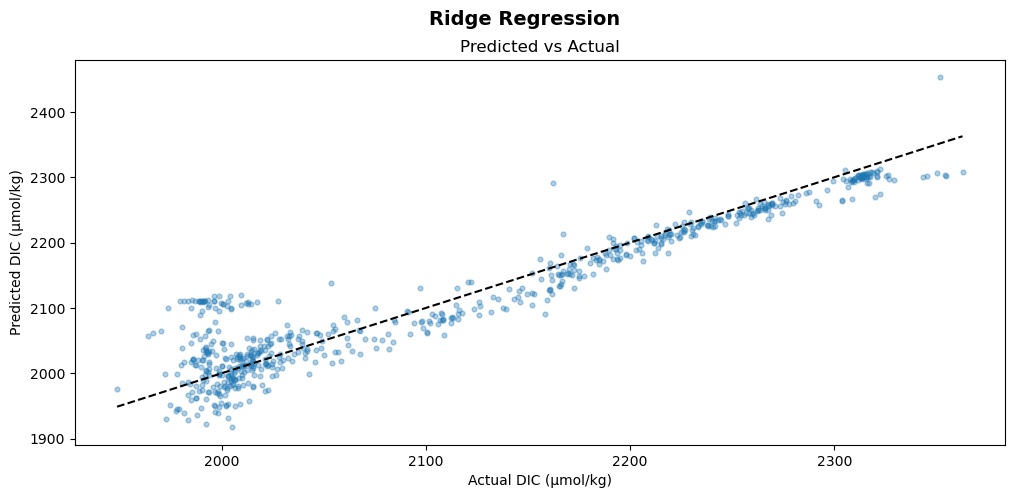

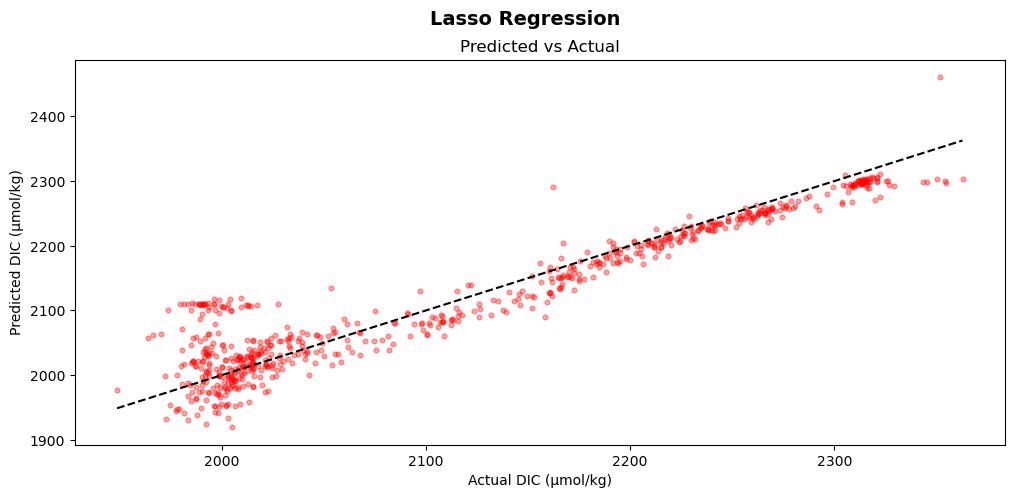

In [25]:
alphas = [0.01, 0.1, 1, 10, 100]

ridge_rmse = [np.sqrt(mean_squared_error(y_val, Ridge(alpha=a).fit(X_train_s, y_train).predict(X_val_s))) for a in alphas]
lasso_rmse = [np.sqrt(mean_squared_error(y_val, Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train).predict(X_val_s))) for a in alphas]

# Ridge
fig, (ax1) = plt.subplots(figsize=(12, 5))
fig.suptitle('Ridge Regression', fontsize=14, fontweight='bold')

ax1.scatter(y_val, ridge_preds, alpha=0.35, s=12)
ax1.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--')
ax1.set_xlabel('Actual DIC (µmol/kg)')
ax1.set_ylabel('Predicted DIC (µmol/kg)')
ax1.set_title('Predicted vs Actual')
plt.show()

# Lasso
fig, (ax1) = plt.subplots(figsize=(12, 5))
fig.suptitle('Lasso Regression', fontsize=14, fontweight='bold')

ax1.scatter(y_val, lasso_preds, alpha=0.35, s=12, color='red')
ax1.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--')
ax1.set_xlabel('Actual DIC (µmol/kg)')
ax1.set_ylabel('Predicted DIC (µmol/kg)')
ax1.set_title('Predicted vs Actual')
plt.show()

# Compare Coefficient Behavior Across λ Values

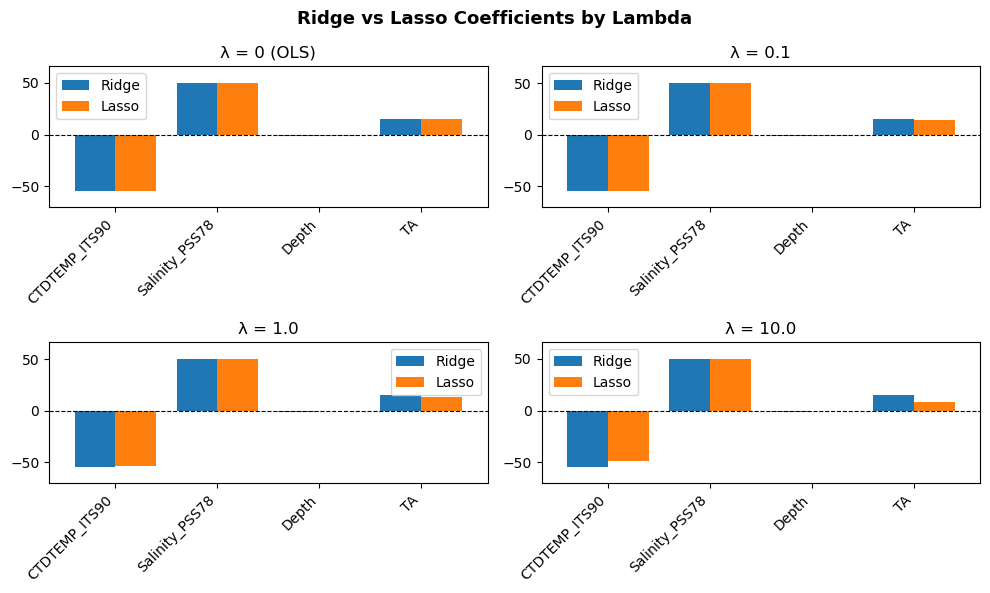

In [24]:
lambdas = [0, 0.1, 1.0, 10.0]
feature_names = ['CTDTEMP_ITS90', 'Salinity_PSS78', 'Depth', 'TA']
data = []

for lam in lambdas:
    if lam == 0:
        ols = LinearRegression().fit(X_train_s, y_train)
        data.append(pd.DataFrame({'Ridge': ols.coef_, 'Lasso': ols.coef_}, index=feature_names))
    else:
        ridge = Ridge(alpha=lam).fit(X_train_s, y_train)
        lasso = Lasso(alpha=lam, max_iter=10000).fit(X_train_s, y_train)
        data.append(pd.DataFrame({'Ridge': ridge.coef_, 'Lasso': lasso.coef_}, index=feature_names))

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, df in enumerate(data):
    df.plot.bar(ax=axes[i], width=0.8)
    axes[i].set_title('λ = 0 (OLS)' if lambdas[i] == 0 else f'λ = {lambdas[i]}')
    axes[i].set_xticklabels(df.index, rotation=45, ha='right')
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    ymin, ymax = min(df.values.min(), 0), max(df.values.max(), 0)
    pad = max((ymax - ymin) * 0.15, 0.5)
    axes[i].set_ylim(ymin - pad, ymax + pad)

plt.suptitle('Ridge vs Lasso Coefficients by Lambda', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Export Results

In [32]:
model = lasso
# final model
test_preds = model.predict(test[features])

submission = pd.DataFrame({"id": test["id"], "DIC": test_preds})
submission.to_csv("submission.csv", index=False)

/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


# Summary - Pat